In [1]:
import sys
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import geopandas as gpd
from shapely.geometry import mapping
from scipy.stats import spearmanr, pearsonr
import pandas as pd
import gc
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests

import warnings
warnings.filterwarnings('ignore')

In [2]:
#dataclass = "/Volumes/New_5TB/ESA_F4R/landcover_classification/"
datac = "/Users/ellendyer/Documents/GitHub/F4R_data/"
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"

datas ="/Users/ellendyer/Library/Mobile Documents/com~apple~CloudDocs/1SHARED_WORK/Work/3_ESA_GRANT/MODEL/Shapefiles/"
shp_cod = gpd.read_file(datas+"congo_basin_evergreen.shp")

datas ="/Users/ellendyer/Library/Mobile Documents/com~apple~CloudDocs/1SHARED_WORK/Work/3_ESA_GRANT/MODEL/Shapefiles/"
shp_cod = gpd.read_file(datas+"geoBoundaries-COD-ADM0.shp")

In [3]:
vclass = xr.open_dataset(datac+'C3S-LC-L4-LCCS-Map-300m-P1Y-2022-v2.1.1.area-subset.30.40.-30.0.nc') 

vclass = vclass['lccs_class'].sel(lat=slice(12,-15),lon=slice(8,31),drop=True)
vclass = vclass.astype('int').load()
#vclass=vclass.where((vclass>=50) & (vclass=<150),drop=True)
#vclass=vclass.where(vclass.isin([10,30,40,50,60,70,80,90,110,120,130,150,200]),drop=True)
vclass_plot=vclass[-1,:,:]

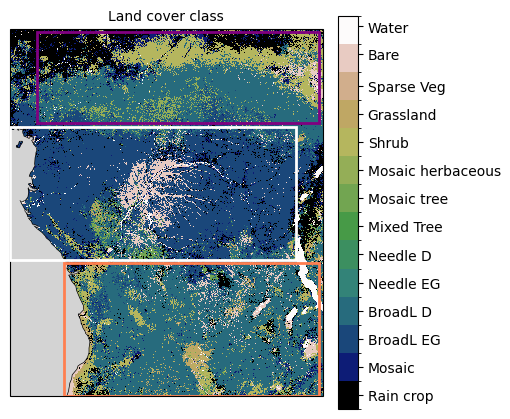

<Figure size 640x480 with 0 Axes>

In [4]:
fig, axs = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()},
                            layout="constrained",
                            figsize=(5,5))

#cmap=plt.cm.tab20b
cmap=plt.cm.gist_earth
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')
cst=vclass_plot.plot.pcolormesh(cmap=cmap,
                    levels=[0, 25, 45, 55, 65, 75, 85, 95, 105, 115, 125, 135, 155, 202, 215],
                    rasterized=True,
                    cbar_kwargs={"label": "","orientation":"vertical","shrink":0.8,
                                 'ticks': [12.5, 35, 50, 60, 70, 80, 90, 100, 110, 120, 130, 145, 185, 210]},
                    transform = ccrs.PlateCarree())
cst.colorbar.ax.set_yticklabels(['Rain crop','Mosaic','BroadL EG','BroadL D',
                                 'Needle EG','Needle D','Mixed Tree','Mosaic tree','Mosaic herbaceous',
                                 'Shrub','Grassland','Sparse Veg','Bare','Water'])#, rotation=45)
axs.add_patch(plt.Rectangle((10, 5.1), 20.7, 6.7, ls="-", lw=2, ec="purple", fc="none",zorder=3))
axs.add_patch(plt.Rectangle((8, -5), 21, 9.8, ls="-", lw=2, ec="white", fc="none",zorder=3))
axs.add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=2, ec="coral", fc="none",zorder=3))
#shp_cod.plot(ax=axs, edgecolor='orange',facecolor='none',lw=2,zorder=2,linestyle='-')
axs.set_title('Land cover class',fontsize=10)
axs.coastlines()
axs.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

plt.savefig(datap+'vclass.png')
plt.show()
plt.clf()